In [1]:
from lxml import etree
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget 

file = '../data/nhtsa-ciss/data/output/28351_20231010006.far'

In [ ]:
class FaroReader:
    def __init__(self, file):
        self.file = file
        self.tree = etree.parse(file)
        self.root = self.tree.getroot()

    def get_scene(self):
        scene = self.root.find('scene')
        data = {"scene_items": {}, "misc": {}}
        layers = scene.findall('layer')
        for layer in layers:
            print(f"Processing layer: {layer.get('n')}")
            items = layer.findall('item')
            for item in items:
                type = item.get('type')
                if type == "polycurve":
                    verts = item.get("pnts")
                    verts = verts.split(';') if verts else []
                    verts = [tuple(map(float, v.split(',')))
                             for v in verts if v]

                    data["scene_items"].setdefault(type, []).append(
                        {"item": item, "verts": verts})
                elif type == "symbol":
                    if item.get('nam') == '':
                        continue
                    print(f"Processing symbol item: {item.get('nam')}")
                    symbol_items = item.findall('item')
                    for sym_item in symbol_items:
                        if sym_item.get('type') == 'symbol':
                            car_symbol = sym_item.find('item[@type="symbol"]')
                            label = sym_item.find('item[@type="label"]')

                        # if sym_item.get('type') == 'polyline':
                        #     transformed_verts, aabb = self.process_symbol_item(
                        #         sym_item)
                        # elif sym_item.get('type') == 'symbol':
                        #     if symbol is not None:
                        #         transformed_verts, aabb = self.process_symbol(symbol)
                        #     else:
                        #         continue
                        # else:
                        #     continue
                         
                        

                        # data["scene_items"].setdefault("polyline", []).append(
                            # {"item": sym_item, "verts": transformed_verts, "aabb": aabb})
                else:
                    data["misc"].setdefault(type, []).append(item)

        return data

    def process_symbol_item(self, item):
        verts = item.get("pnts")
        verts = verts.split(';') if verts else []
        verts = [tuple(map(float, v.split(',')))
                 for v in verts if v]

        tx = float(item.get('tx', '0'))
        ty = float(item.get('ty', '0'))
        tz = float(item.get('tz', '0'))

        transformed_verts = [(x + tx, y + ty, z + tz)
                             for (x, y, z) in verts]

        xs = [v[0] for v in transformed_verts]
        ys = [v[1] for v in transformed_verts]
        zs = [v[2] for v in transformed_verts]
        aabb = {
            "min": (min(xs), min(ys), min(zs)),
            "max": (max(xs), max(ys), max(zs))
        }

        return transformed_verts, aabb
    
    def process_symbol(self, symbol):
        symbol_items = symbol.findall('item')
        for sym_item in symbol_items:
            if sym_item.get('type') == 'polyline':
                transformed_verts, aabb = self.process_symbol_item(
                    sym_item)
                return transformed_verts, aabb

    def get_properties(self):
        return self.root.find('properties')

    def get_thumbnail(self):
        return self.root.find('thumb')


reader = FaroReader(file)
scene = reader.get_scene()
# print(scene)

IndentationError: expected an indented block after 'if' statement on line 30 (2092373283.py, line 44)

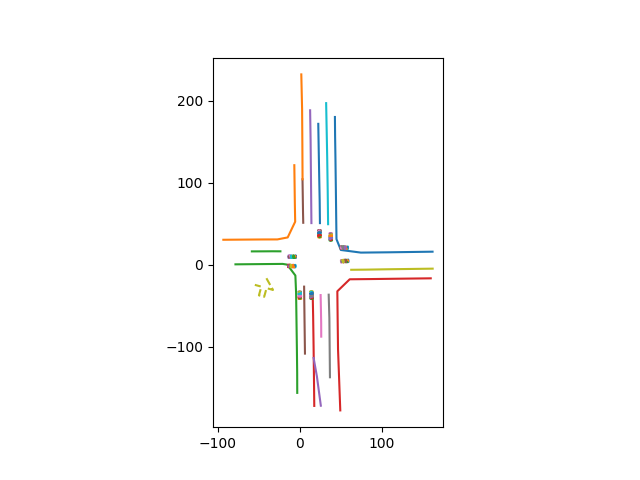

In [ ]:
# 2d plotting of polycurves
fig = plt.figure()
ax = fig.add_subplot(111)
for polycurve in scene["scene_items"].get("polycurve", []):
    verts = polycurve["verts"]
    if verts:
        xs, ys, _ = zip(*verts)
        ax.plot(xs, ys)
for polyline in scene["scene_items"].get("polyline", []):
    verts = polyline["verts"]
    if verts:
        xs, ys, _ = zip(*verts)
        ax.plot(xs, ys, linestyle='--')
# set x range to -200 to 200
# ax.set_xlim(-200, 200)
# ax.set_ylim(-200, 200)
ax.set_aspect('equal')

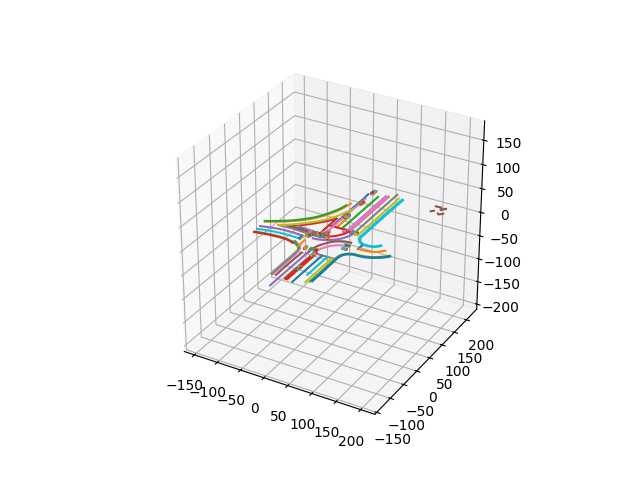

In [ ]:
#3d 
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# collect global bounds across all polycurves
xmin, xmax = float('inf'), float('-inf')
ymin, ymax = float('inf'), float('-inf')
zmin, zmax = float('inf'), float('-inf')

for polycurve in scene["scene_items"].get("polycurve", []):
    verts = polycurve["verts"]
    if verts:
        xs, ys, zs = zip(*verts)
        ax.plot(xs, ys, zs)
        xmin, xmax = min(xmin, min(xs)), max(xmax, max(xs))
        ymin, ymax = min(ymin, min(ys)), max(ymax, max(ys))
        zmin, zmax = min(zmin, min(zs)), max(zmax, max(zs))

for polyline in scene["scene_items"].get("polyline", []):
    verts = polyline["verts"]
    if verts:
        xs, ys, zs = zip(*verts)
        ax.plot(xs, ys, zs, linestyle='--')
        xmin, xmax = min(xmin, min(xs)), max(xmax, max(xs))
        ymin, ymax = min(ymin, min(ys)), max(ymax, max(ys))
        zmin, zmax = min(zmin, min(zs)), max(zmax, max(zs))

# set equal aspect ratio
xmid, ymid, zmid = (xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2
max_range = max(xmax - xmin, ymax - ymin, zmax - zmin)
half = max_range / 2

ax.set_xlim(xmid - half, xmid + half)
ax.set_ylim(ymid - half, ymid + half)
ax.set_zlim(zmid - half, zmid + half)
ax.set_box_aspect((1, 1, 1))